# Propagule size tracking from RBG image

## 1. Documentation and Imports


Created on 17-02-2021

Author: Valentin Laplaud

This code will load time series of propagules image in color, identify the propagule, and measure its size in time.

In [1]:

# plotting stuff
import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler
colorcycle = [plt.get_cmap('gist_rainbow')(1. * i/30) for i in range(30)]
mpl.rcParams['axes.prop_cycle'] = cycler(color=colorcycle)

# numbers handling
import numpy as np
import pandas as pd

# images handling
from skimage import io
from skimage.filters import threshold_otsu, gaussian, laplace
from skimage.measure import label, regionprops_table
from skimage.util import invert
from skimage.morphology import binary_opening, binary_closing, remove_small_holes

# to hide known warnings
import warnings

# General system functions
import os
import shutil
import sys

import time

# my functions
sys.path.append('../')
import VallapFunc as vf

## 2. Define data processing functions



### 2.0 Create binary circle element for image processing

### 2.1 Image binarization

GetHue : Computes Hue from RGB image. Also applies a gaussian blur for smoothness.

Binarize : Threshold the Hue image using the Otsu threshold. Then opens the image using a circle of 30 µm.

create_circular_mask : create the circle 

In [2]:
def GetHue(RGBimg):
    
    warnings.filterwarnings("ignore")   

    HueImg = np.zeros(RGBimg.shape[0:2]) # initialize Hue img

    Maxes = RGBimg.argmax(axis=2)
    Mines = RGBimg.argmin(axis=2)

    # when red is max
    mask = Maxes == 0
    HueImg[mask] = (RGBimg[mask,1]-RGBimg[mask,2])/(RGBimg[mask,:].max(axis=1)-RGBimg[mask,:].min(axis=1))

    # when green is max
    mask = Maxes == 1
    HueImg[mask] = 2 + (RGBimg[mask,2]-RGBimg[mask,0])/(RGBimg[mask,:].max(axis=1)-RGBimg[mask,:].min(axis=1))

    # when blue is max
    mask = Maxes == 2
    HueImg[mask] = 4 + (RGBimg[mask,0]-RGBimg[mask,1])/(RGBimg[mask,:].max(axis=1)-RGBimg[mask,:].min(axis=1))


    # correct for nans
    HueImg[np.isnan(HueImg)] = 5

    HueImg = (HueImg/6)%1
          
    if DebugPlots:
                
        fig, (ax0, ax1) = plt.subplots(ncols=2, dpi=200)
        
        fig.suptitle('Debug plots for "GetHue" function :')
        ax0.imshow(RGBimg)
        ax0.set_title("RGB image")
        ax0.axis('off')
        ax1.imshow(HueImg, cmap='gray')
        ax1.set_title("Hue image")
        ax1.axis('off')
        
        plt.show()
        
        print('')
    
    return(HueImg)

def Binarize(Img, Scale):
    
    BWimg = invert(Img > threshold_otsu(Img)) # apply threshold 
    
    # to avoid filling up to the edges
    BWimg[0:9,0:] = 0    
    BWimg[0:,0:9] = 0 
    BWimg[0:,BWimg.shape[1]-10:BWimg.shape[1]]= 0
    BWimg[BWimg.shape[0]-10:BWimg.shape[0],0:] = 0
    
    FilledBWimg = remove_small_holes(BWimg, area_threshold=1e5) # fills dark regions
    
    Size = np.round(30*Scale) # 30µm in pixels
    
    selem = create_circular_mask(Size,Size) # create circular element for opening

    FinalImg = binary_opening(FilledBWimg,selem) # image opening
    
    if DebugPlots:        
       
        fig, [[ax0, ax1], [ax2, ax3]] = plt.subplots(nrows = 2, ncols=2,dpi = 200)    
        fig.suptitle('Debug plots for "Binarize" function :')
        ax0.imshow(Img, cmap='gray')
        ax0.set_title("Original image")
        ax0.axis('off')
        ax1.imshow(BWimg, cmap='gray')
        ax1.set_title("Thresholded image")
        ax1.axis('off')
        ax2.imshow(FilledBWimg, cmap='gray')
        ax2.set_title("Filled image")
        ax2.axis('off') 
        ax3.imshow(FinalImg, cmap='gray')
        ax3.set_title("Opened image")
        ax3.axis('off')        
        
        plt.show()
        
        print('')
    
    return(FinalImg)

def create_circular_mask(h, w, center=None, radius=None):

    if center is None: # use the middle of the image
        center = (int(w/2), int(h/2))
    if radius is None: # use the smallest distance between the center and image walls
        radius = min(center[0], center[1], w-center[0], h-center[1])

    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y-center[1])**2)

    mask = dist_from_center <= radius
    return mask

### 2.3 Identify biggest object and returns its geometrical properties

Needs a binary image

In [3]:
def GetProps(BWimg,Scale):
    
    # extract properties from regions in the thresholded image
    label_img = label(BWimg)
    
    regions = regionprops_table(label_img, properties=('area','perimeter','bbox','feret_diameter_max'))
    
    propstable = pd.DataFrame(regions) # convert into dataframe

    idx = np.argmax(propstable.area) # index reprensting the biggest object
                         
    pxArea = propstable.at[idx, 'area']
    
    Area = pxArea/Scale**2

    pxLength = propstable.at[idx, 'feret_diameter_max']
    
    Length = pxLength/Scale
    
    BBOX = [propstable.at[idx, 'bbox-0'], propstable.at[idx, 'bbox-1'],
            propstable.at[idx, 'bbox-2'], propstable.at[idx, 'bbox-3']]
                    
    return(Area, Length, BBOX)

## 3. Define main functions

### 3.1 Analysis function

Needs the list of experiments to analyze, the Path where to the files, le time scale (FramesPerHours), and the spatial scale (px/µm)

In [4]:
def MainAnalysis(StackList, P, FPH, Scale):

    Data = pd.DataFrame(data=None,columns=['Time (min)','FocusValue','Size (mm²)','Normalized Size','Height(µm)','Bounding box (px)']) 


    for s in StackList:

        print('Processing ' + s + ' :')    

        RGBstack = io.imread(P + '\\' + s + '.tif') # get the tiff stack

        # Savefolders for Hue and Binary stacks
        if not os.path.exists(P + '\\Processed\\' + s + '_Hue'):
            # shutil.rmtree(P + '\\' + s + '_Hue') # remove folder and contents
            os.mkdir(P + '\\Processed\\' + s + '_Hue') # create folder
            isHue = False
        else:
            isHue = True

        if not os.path.exists(P + '\\Processed\\' + s + '_Binarized'):
            # shutil.rmtree(P + '\\' + s + '_Binarized') # remove folder and contents
            os.mkdir(P + '\\Processed\\' + s + '_Binarized') # create folder
            isBin = False
        else:
            isBin = True


        Area = np.zeros(len(RGBstack)) # initialize result vector
        Height = np.zeros(len(RGBstack)) # initialize result vector
        BBOX = np.zeros([len(RGBstack),4]) # initialize result vector

        # pre-process images
        for i in range(len(RGBstack)):

            FocusValue = np.sum(np.absolute(laplace(np.max(RGBstack[i],2))))
            
            # Hue channel computation
            if not isHue:
                print('Computing Hue for image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(10), flush=True, end = '\r')
                HueImg = GetHue(gaussian(RGBstack[i],2,multichannel=True)) 
                io.imsave(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif', np.uint8(HueImg*255), plugin='tifffile')

            else:
                if os.path.exists(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif'):
                    
                    HueImg = io.imread(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif')
                    
                else:
                    print('Computing Hue for image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(10), flush=True, end = '\r')
                    HueImg = GetHue(gaussian(RGBstack[i],2,multichannel=True)) 
                    io.imsave(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif', np.uint8(HueImg*255), plugin='tifffile')

            # Binarization      
            if not isBin:
                print('Binarization of image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(15), flush=True, end = '\r')
                BinImg = Binarize(HueImg,Scale)
                io.imsave(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif', np.uint8(BinImg*255), plugin='tifffile')
            
            else:
                if os.path.exists(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif'):
                    BinImg = io.imread(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif')  
                else:
                    print('Binarization of image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(15), flush=True, end = '\r')
                    BinImg = Binarize(HueImg,Scale)
                    io.imsave(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif', np.uint8(BinImg*255), plugin='tifffile')
            
            # geometric features
            
            print('Measuring geometry on image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(10), flush=True, end = '\r')

            Area[i], Height, BBOX = GetProps(BinImg,Scale)
            
            NormArea = Area[i]/Area[0]
            
            # creating dataframe for current image
            DataCurr = pd.DataFrame(data=[[ i/FPH*60,FocusValue, Area[i]/1e6, NormArea,Height,BBOX]],index = [s],
                                        columns=['Time (min)','FocusValue','Size (mm²)','Normalized Size','Length(µm)','Bounding box (px)']) 

            Data = Data.append(DataCurr) # adding to global dataframe
            

        # identifying image wih good focus
        GoodFocusTimeList = Data.at[s,'Time (min)'].to_numpy()[np.argwhere(np.concatenate(([0],np.diff(Data.at[s,'FocusValue'])))/Data.at[s,'FocusValue'].median()>-0.05)]
        
        Data.at[s, 'GoodFocus'] = Data.loc[s].apply(
        lambda row: np.isin(row['Time (min)'],GoodFocusTimeList) , axis = 1)
                 
    
        print('Processing done for ' + str(len(RGBstack)) + '/' + str(len(RGBstack)) + ' images'.ljust(20), flush=True)

        
    return(Data)



### 3.2 Plotting function

Needs list of experiment names, Dataframe from analysis, and a savepath for the figures

In [5]:
def PlotResults(StackList, Data, P, Title, **kwargs):

    #init and read kwargs
    Trap = False # default value
    soloGraphs = False
    
    for key, value in kwargs.items(): 
        if key == 'Trapped':
            Trap = value
        elif key == 'solo':
            soloGraphs = value
        else:
            print('Unknown key : ' + key+ '. Kwarg ignored.')
         
    # check existence of figure folder, if absent, create it
    if not os.path.exists(P + '\\Figures'):
            os.mkdir(P + '\\Figures') # create folder
    
    # plot figures
    
    if soloGraphs: # plot individual graphs
    
        for s in StackList:
            

            fig1 = plt.figure(dpi = 200)
            fig1.suptitle(s + ' - Size vs. time')
            plt.xlabel('Time (min)')
            plt.ylabel('Size (mm²)')
            

            xTime = Data.at[s, 'Time (min)'].to_numpy()[Data.at[s, 'GoodFocus']==True]
        
            
            PropBBOX = Data.at[s, 'Bounding box (px)']

            plt.plot(xTime,Data.at[s, 'Size (mm²)'].to_numpy()[Data.at[s, 'GoodFocus']==True],'-o',ms=3,figure=fig1,label=s)

            # if there is a trap, find out when th ppgls touches up and bottom wall
            if Trap:
                trapdata =vf.LoadImageJResults(P + '\\' + s + '_Trap.txt', ['BX','BY','Width','Height'])
                TrapBBOX = [trapdata.at[0, 'BY'], trapdata.at[0, 'BX'],trapdata.at[0, 'BY'] + trapdata.at[0, 'Height'] ,
                        trapdata.at[0, 'BX'] + trapdata.at[0, 'Width']]

                BBOXDiff = PropBBOX - TrapBBOX            
                idxTouch = np.argwhere(np.logical_and(BBOXDiff[0:,0]<0, BBOXDiff[0:,2]>0))

                plt.plot(xTime[idxTouch],Data.at[s, 'Size (mm²)'][idxTouch],'-or',lw=0.5,ms=1.5,figure=fig1,label='Touching UpDown')
                plt.legend(prop={'size': 4})

                fig1.savefig(P + '\\Figures\\' + s + '_SizeTime.png')    


    fig2 = plt.figure(dpi = 200)
    fig2.suptitle(Title + ' - Norm Size vs. time')
    plt.xlabel('Time (min)')
    plt.ylabel('Size (normalized)')



    
    for s in StackList:
        
        # identifying image wih good focus
        GoodFocusList = np.argwhere(np.diff(Data.at[s,'FocusValue'])/Data.at[s,'FocusValue'].median()<0.05)
            
        xTime = Data.at[s, 'Time (min)'].to_numpy()[Data.at[s, 'GoodFocus']==True]
        
        plt.plot(xTime,Data.at[s, 'Normalized Size'].to_numpy()[Data.at[s, 'GoodFocus']==True],'-o',ms=3,figure=fig2,label=s)
        
    plt.legend(prop={'size': 4})
    fig2.savefig(P + '\\Figures\\NormSizeTime_' + Title + '.png')
    
    
        
    

## 4. Enter data and run

In [6]:
DebugPlots = True # Display intermediate plots along the way

# Paths to data
P1 = r'd:\Users\laplaud\Desktop\PostDoc\Data\Microflu\Manips\2021.02.16'

P2 = r'd:\Users\laplaud\Desktop\PostDoc\Data\Microflu\Manips\2021.03.18'

P3 = r'd:\Users\laplaud\Desktop\PostDoc\Data\Microflu\Manips\2021.03.19'


# List of stacks to analyse

# experiment of 16-02-2021
# outside traps
StackListFree210216 = ['Propagule-03','Propagule-09','Propagule-12','Propagule-18','Propagule-19',
                'Propagule-24','Propagule-25']

# inside traps
StackListTrapped210216 = ['Propagule-04','Propagule-06','Propagule-07','Propagule-08',
                    'Propagule-13','Propagule-14','Propagule-15','Propagule-16','Propagule-17',
                    'Propagule-20','Propagule-21','Propagule-22','Propagule-23','Propagule-26',
                    'Propagule-27','Propagule-28','Propagule-29','Propagule-30']


# experiments of 18-03-2021
StackList210318 = ['PPG1','PPG2','PPG3','PPG4','PPG5','PPG6','PPG7','PPG8','PPG9','PPG10','PPG11',
                   'PPG12','PPG13','PPG14','PPG15','PPG16','PPG17','PPG18','PPG19','PPG20','PPG21',
                   'PPG22','PPG23','PPG24','PPG25','PPG26','PPG27','PPG28','PPG29']

# experiments of 19-03-2021 (68h, cropped when air arrives)
StackList210319 = ['PPG1','PPG2','PPG3','PPG4','PPG5','PPG6','PPG8','PPG9','PPG10','PPG11',
                   'PPG12','PPG13','PPG14','PPG15','PPG16','PPG17','PPG18','PPG19','PPG20','PPG21',
                   'PPG22','PPG23']




FPH = 2 # Framerate (frames per hour)
Scale1 = 2.5 # Spatial scale (px/µm) 16-02-2021

Scale2 = 0.44 # Spatial scale (px/µm) 18-03-2021

Scale3 = 0.58 # Spatial scale (px/µm) 19-03-2021


In [7]:
## Analyze 

#DataFree210216 = MainAnalysis(StackListFree210216, P1, FPH, Scale1)

#DataTrapped210216 = MainAnalysis(StackListTrapped210216, P1, FPH, Scale1)

#Data210318 = MainAnalysis(StackList210318, P2, FPH, Scale2)

Data210319 = MainAnalysis(StackList210319, P3, FPH, Scale3)


Processing PPG1 :
Processing done for 134/134 images             
Processing PPG2 :
Processing done for 134/134 images             
Processing PPG3 :
Processing done for 108/108 images             
Processing PPG4 :
Processing done for 134/134 images             
Processing PPG5 :
Processing done for 109/109 images             
Processing PPG6 :
Processing done for 63/63 images             
Processing PPG8 :
Processing done for 52/52 images             
Processing PPG9 :
Processing done for 73/73 images             
Processing PPG10 :
Processing done for 82/82 images             
Processing PPG11 :
Processing done for 89/89 images             
Processing PPG12 :
Processing done for 75/75 images             
Processing PPG13 :
Processing done for 74/74 images             
Processing PPG14 :
Processing done for 111/111 images             
Processing PPG15 :
Processing done for 75/75 images             
Processing PPG16 :
Processing done for 75/75 images             
Processing PPG17 :
Pr

In [8]:
## Save data

#DataFree210216.to_csv(P1 + '\\SizeDataFreePpgles210216.csv',index_label = 'Ind')
#DataTrapped210216.to_csv(P1 + '\\SizeDataTrappedPpgles210216.csv',index_label = 'Ind')
#Data210318.to_csv(P2 + '\\SizeData210318.csv',index_label = 'Ind')
Data210319.to_csv(P3 + '\\SizeData210319.csv',index_label = 'Ind')

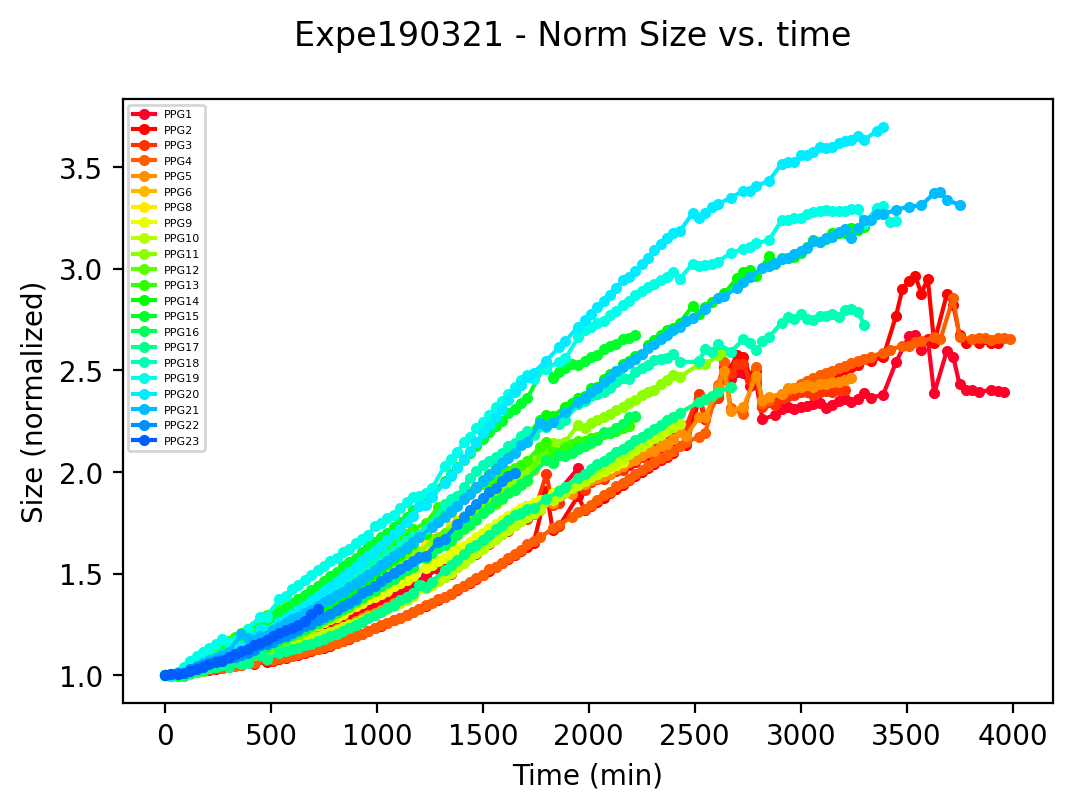

In [9]:
## plot result

#PlotResults(StackListFree210216, DataFree210216, P1, 'Free_Propagules', Trapped=False, solo=False)

#PlotResults(StackListTrapped210216, DataTrapped210216, P1, 'Trapped_Propagules', Trapped=True, solo=False)

#PlotResults(StackList210318, Data210318, P2, 'Expe180321', solo=False) 

PlotResults(StackList210319, Data210319, P3, 'Expe190321', solo=False) 

# Test Zone

In [13]:
print('r'.ljust(10))

r         
